## With the given dataset

In [99]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Step 1: Load dataset (Iris dataset)
iris = datasets.load_iris()
X = iris.data[:, :2]  # Use first 2 features
y = iris.target

# Step 2: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 3: Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

# Step 4: Predict
y_pred = svm_model.predict(X_test)

# Step 5: Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Predictions:", y_pred)


Accuracy: 0.8
Predictions: [1 0 2 1 2 0 1 2 1 1 2 0 0 0 0 2 2 1 1 2 0 1 0 2 2 2 2 2 0 0 0 0 2 0 0 1 2
 0 0 0 1 2 2 0 0]


In [100]:
import pandas as pd

## With own dataset 

In [101]:
df = pd.read_csv("../datasets/UniversalBank.xls")
df

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


In [102]:
df.corr()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,1.000000,-0.008473,-0.008326,-0.017695,0.013432,-0.016797,-0.024675,0.021463,-0.013920,-0.024801,-0.016972,-0.006909,-0.002528,0.017028
Age,-0.008473,1.000000,0.994215,-0.055269,-0.029216,-0.046418,-0.052012,0.041334,-0.012539,-0.007726,-0.000436,0.008043,0.013702,0.007681
Experience,-0.008326,0.994215,1.000000,-0.046574,-0.028626,-0.052563,-0.050077,0.013152,-0.010582,-0.007413,-0.001232,0.010353,0.013898,0.008967
Income,-0.017695,-0.055269,-0.046574,1.000000,-0.016410,-0.157501,0.645984,-0.187524,0.206806,0.502462,-0.002616,0.169738,0.014206,-0.002385
ZIP Code,0.013432,-0.029216,-0.028626,-0.016410,1.000000,0.011778,-0.004061,-0.017377,0.007383,0.000107,0.004704,0.019972,0.016990,0.007691
Family,-0.016797,-0.046418,-0.052563,-0.157501,0.011778,1.000000,-0.109275,0.064929,-0.020445,0.061367,0.019994,0.014110,0.010354,0.011588
CCAvg,-0.024675,-0.052012,-0.050077,0.645984,-0.004061,-0.109275,1.000000,-0.136124,0.109905,0.366889,0.015086,0.136534,-0.003611,-0.006689
Education,0.021463,0.041334,0.013152,-0.187524,-0.017377,0.064929,-0.136124,1.000000,-0.033327,0.136722,-0.010812,0.013934,-0.015004,-0.011014
Mortgage,-0.013920,-0.012539,-0.010582,0.206806,0.007383,-0.020445,0.109905,-0.033327,1.000000,0.142095,-0.005411,0.089311,-0.005995,-0.007231
Personal Loan,-0.024801,-0.007726,-0.007413,0.502462,0.000107,0.061367,0.366889,0.136722,0.142095,1.000000,0.021954,0.316355,0.006278,0.002802


In [103]:
df2 = df[['Education','Family','Income','Personal Loan','Mortgage','Age','Securities Account','CreditCard']]
df2

,Education,Family,Income,Personal Loan,Mortgage,Age,Securities Account,CreditCard
0,1,4,49,0,0,25,1,0
1,1,3,34,0,0,45,1,0
2,1,1,11,0,0,39,0,0
3,2,1,100,0,0,35,0,0
4,2,4,45,0,0,35,0,1
...,...,...,...,...,...,...,...,...
4995,3,1,40,0,0,29,0,0
4996,1,4,15,0,85,30,0,0
4997,3,2,24,0,0,63,0,0
4998,2,3,49,0,0,65,0,0


In [104]:
df2.isnull().sum()

Education             0
Family                0
Income                0
Personal Loan         0
Mortgage              0
Age                   0
Securities Account    0
CreditCard            0
dtype: int64

In [105]:
df2['Personal Loan'].value_counts()

Personal Loan
0    4520
1     480
Name: count, dtype: int64

In [106]:
df2.shape

(5000, 8)

In [107]:
x = df2.drop(columns=['Personal Loan'])
y = df2['Personal Loan']


In [108]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_res, y_res = smote.fit_resample(x, y)
print(x_res.shape, y_res.shape)

(9040, 7) (9040,)


In [109]:
y_res.value_counts()

Personal Loan
0    4520
1    4520
Name: count, dtype: int64

In [110]:
df2.shape

(5000, 8)

In [111]:
X_train, X_test, y_train, y_test = train_test_split(x_res, y_res, test_size=0.3, random_state=42)

In [114]:
X_train.shape

(6328, 7)

In [118]:
# Step 3: Train SVM
svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = svm_model.predict(X_test)

In [117]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# Step 5: Evaluate
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :",precision_score(y_test,y_pred))
print("Recall :",recall_score(y_test,y_pred))
print("F1 Score :",f1_score(y_test,y_pred))

Accuracy : 0.8727876106194691
Precision : 0.858600583090379
Recall : 0.8863807373965388
F1 Score : 0.8722695298037764


In [121]:
x_res

,Education,Family,Income,Mortgage,Age,Securities Account,CreditCard
0,1,4,49,0,25,1,0
1,1,3,34,0,45,1,0
2,1,1,11,0,39,0,0
3,2,1,100,0,35,0,0
4,2,4,45,0,35,0,1
...,...,...,...,...,...,...,...
9035,2,3,83,0,48,0,0
9036,2,1,124,0,33,0,0
9037,1,4,139,198,57,0,0
9038,1,3,178,142,30,0,0


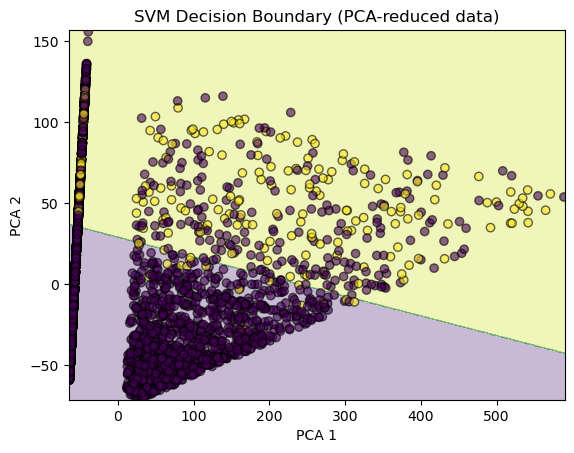

In [123]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# ----- PCA Visualization -----
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)

svm_pca = SVC(kernel='linear', class_weight='balanced')
svm_pca.fit(X_pca, y)

# Meshgrid for decision boundary
import numpy as np
xx, yy = np.meshgrid(
    np.linspace(X_pca[:, 0].min()-1, X_pca[:, 0].max()+1, 500),
    np.linspace(X_pca[:, 1].min()-1, X_pca[:, 1].max()+1, 500)
)

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary in PCA space
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolors='k', alpha=0.6)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("SVM Decision Boundary (PCA-reduced data)")
plt.show()
